# Week 2 Task: Logistics Data Collection, Cleaning and Preprocessing

In [1]:
# Week 2 Task: Logistics Data Collection, Cleaning and Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the logistics dataset

file_path = r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-2\cleaned_logistics_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display first 5 records

df.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [4]:
# Check number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 32065
Number of Columns: 26


In [5]:
# Display all column names

print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Columns in the dataset:

1 - timestamp
2 - vehicle_gps_latitude
3 - vehicle_gps_longitude
4 - fuel_consumption_rate
5 - eta_variation_hours
6 - traffic_congestion_level
7 - warehouse_inventory_level
8 - loading_unloading_time
9 - handling_equipment_availability
10 - order_fulfillment_status
11 - weather_condition_severity
12 - port_congestion_level
13 - shipping_costs
14 - supplier_reliability_score
15 - lead_time_days
16 - historical_demand
17 - iot_temperature
18 - cargo_condition_status
19 - route_risk_level
20 - customs_clearance_time
21 - driver_behavior_score
22 - fatigue_monitoring_score
23 - disruption_likelihood_score
24 - delay_probability
25 - risk_classification
26 - delivery_time_deviation


In [6]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

In [7]:
# Statistical summary of numerical columns

df.describe()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,...,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,...,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,...,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,...,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,...,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,...,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,...,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,...,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


In [8]:
# Check missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing Percentage": (missing_values.values / len(df)) * 100
})

missing_summary

,Column,Missing Values,Missing Percentage
0,timestamp,0,0.0
1,vehicle_gps_latitude,0,0.0
2,vehicle_gps_longitude,0,0.0
3,fuel_consumption_rate,0,0.0
4,eta_variation_hours,0,0.0
5,traffic_congestion_level,0,0.0
6,warehouse_inventory_level,0,0.0
7,loading_unloading_time,0,0.0
8,handling_equipment_availability,0,0.0
9,order_fulfillment_status,0,0.0


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Step 3---Data Quality Analysis & Outlier Detection

In [11]:
# Check data types of all columns

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

dtype_summary

,Column,Data Type
0,timestamp,object
1,vehicle_gps_latitude,float64
2,vehicle_gps_longitude,float64
3,fuel_consumption_rate,float64
4,eta_variation_hours,float64
5,traffic_congestion_level,float64
6,warehouse_inventory_level,float64
7,loading_unloading_time,float64
8,handling_equipment_availability,float64
9,order_fulfillment_status,float64


In [12]:
# Check number of unique values in each column

unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

unique_summary

,Column,Unique Values
0,timestamp,32065
1,vehicle_gps_latitude,32065
2,vehicle_gps_longitude,32065
3,fuel_consumption_rate,32037
4,eta_variation_hours,32065
5,traffic_congestion_level,32065
6,warehouse_inventory_level,32065
7,loading_unloading_time,32065
8,handling_equipment_availability,32065
9,order_fulfillment_status,32065


In [13]:
# Identify numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
for col in numeric_columns:
    print("-", col)

print("\nTotal numerical columns:", len(numeric_columns))

Numerical columns:
- vehicle_gps_latitude
- vehicle_gps_longitude
- fuel_consumption_rate
- eta_variation_hours
- traffic_congestion_level
- warehouse_inventory_level
- loading_unloading_time
- handling_equipment_availability
- order_fulfillment_status
- weather_condition_severity
- port_congestion_level
- shipping_costs
- supplier_reliability_score
- lead_time_days
- historical_demand
- iot_temperature
- cargo_condition_status
- route_risk_level
- customs_clearance_time
- driver_behavior_score
- fatigue_monitoring_score
- disruption_likelihood_score
- delay_probability
- delivery_time_deviation

Total numerical columns: 24


In [14]:
# Identify categorical/text columns

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
for col in categorical_columns:
    print("-", col)

print("\nTotal categorical columns:", len(categorical_columns))

Categorical columns:
- timestamp
- risk_classification

Total categorical columns: 2


In [15]:
# Detect outliers using the IQR method

outlier_summary = []

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,vehicle_gps_latitude,31.280550,44.453655,13.173105,11.520892,64.213313,0,0.000000
1,vehicle_gps_longitude,-106.253913,-73.079367,33.174545,-156.015731,-23.317549,0,0.000000
2,fuel_consumption_rate,5.019984,9.669944,4.649960,-1.954956,16.644883,2536,7.908935
3,eta_variation_hours,1.185744,4.884355,3.698611,-4.362173,10.432272,0,0.000000
4,traffic_congestion_level,1.474720,8.534902,7.060181,-9.115552,19.125174,0,0.000000
5,warehouse_inventory_level,16.051635,540.597991,524.546356,-770.767899,1327.417525,0,0.000000
6,loading_unloading_time,0.774798,3.734188,2.959390,-3.664287,8.173273,0,0.000000
7,handling_equipment_availability,0.017108,0.553595,0.536487,-0.787622,1.358326,0,0.000000
8,order_fulfillment_status,0.277096,0.938160,0.661064,-0.714500,1.929756,0,0.000000
9,weather_condition_severity,0.144014,0.849823,0.705809,-0.914700,1.908536,0,0.000000


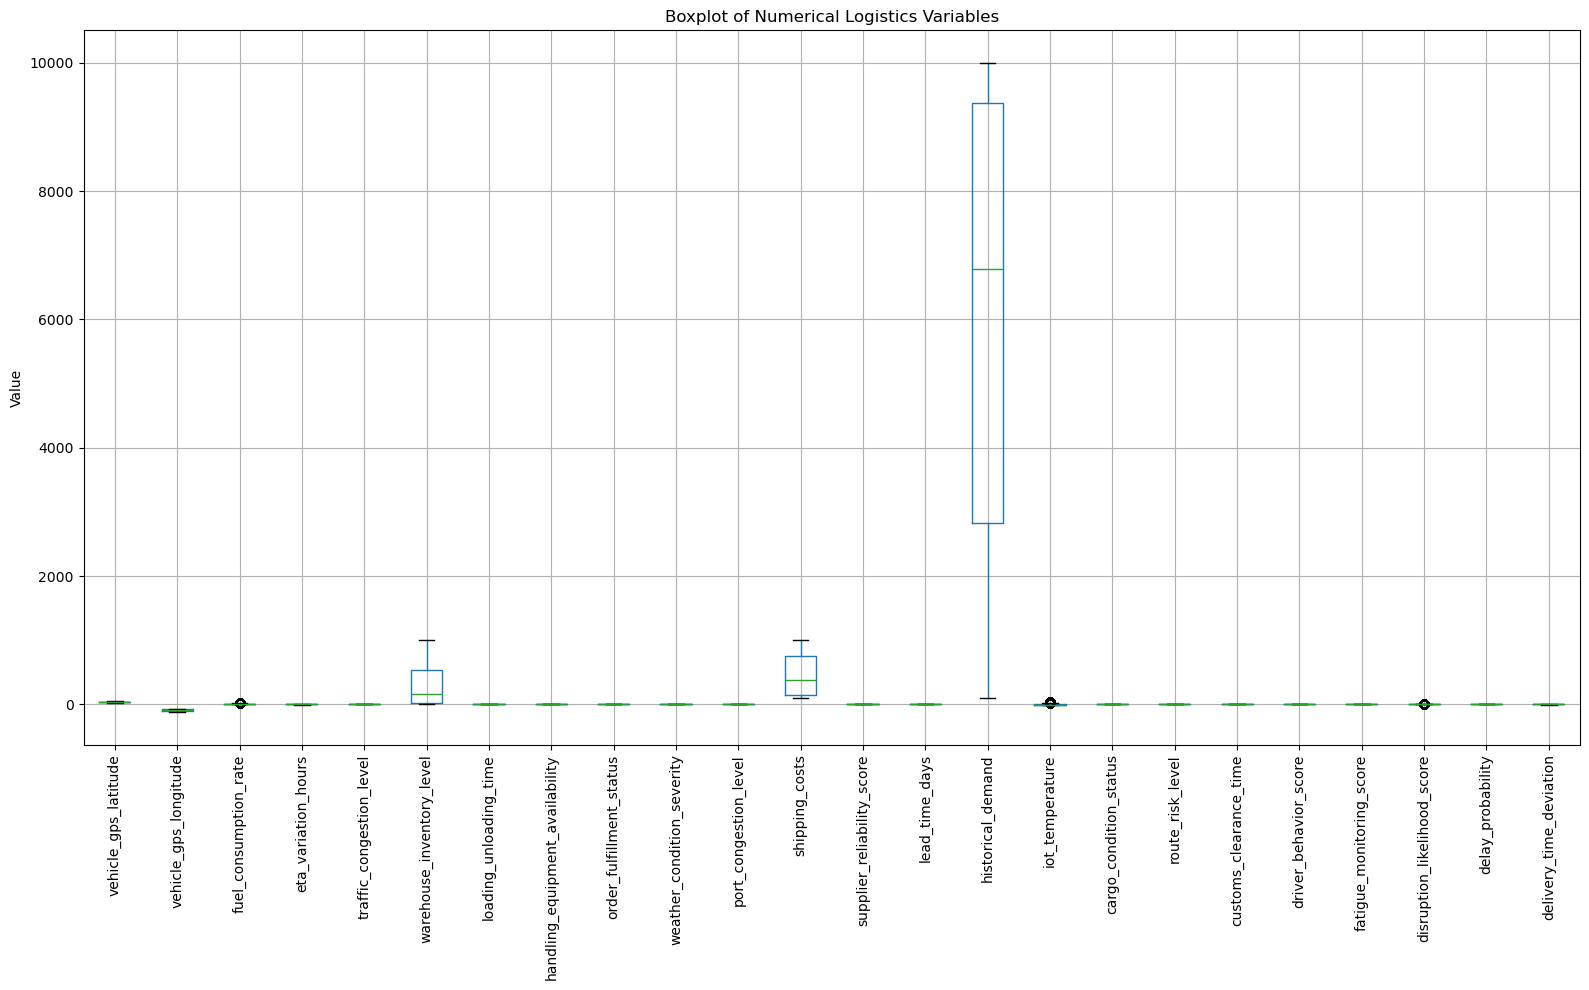

In [16]:
# Create boxplots for numerical variables

plt.figure(figsize=(16, 10))

df[numeric_columns].boxplot()

plt.title("Boxplot of Numerical Logistics Variables")
plt.xticks(rotation=90)
plt.ylabel("Value")

plt.tight_layout()
plt.show()

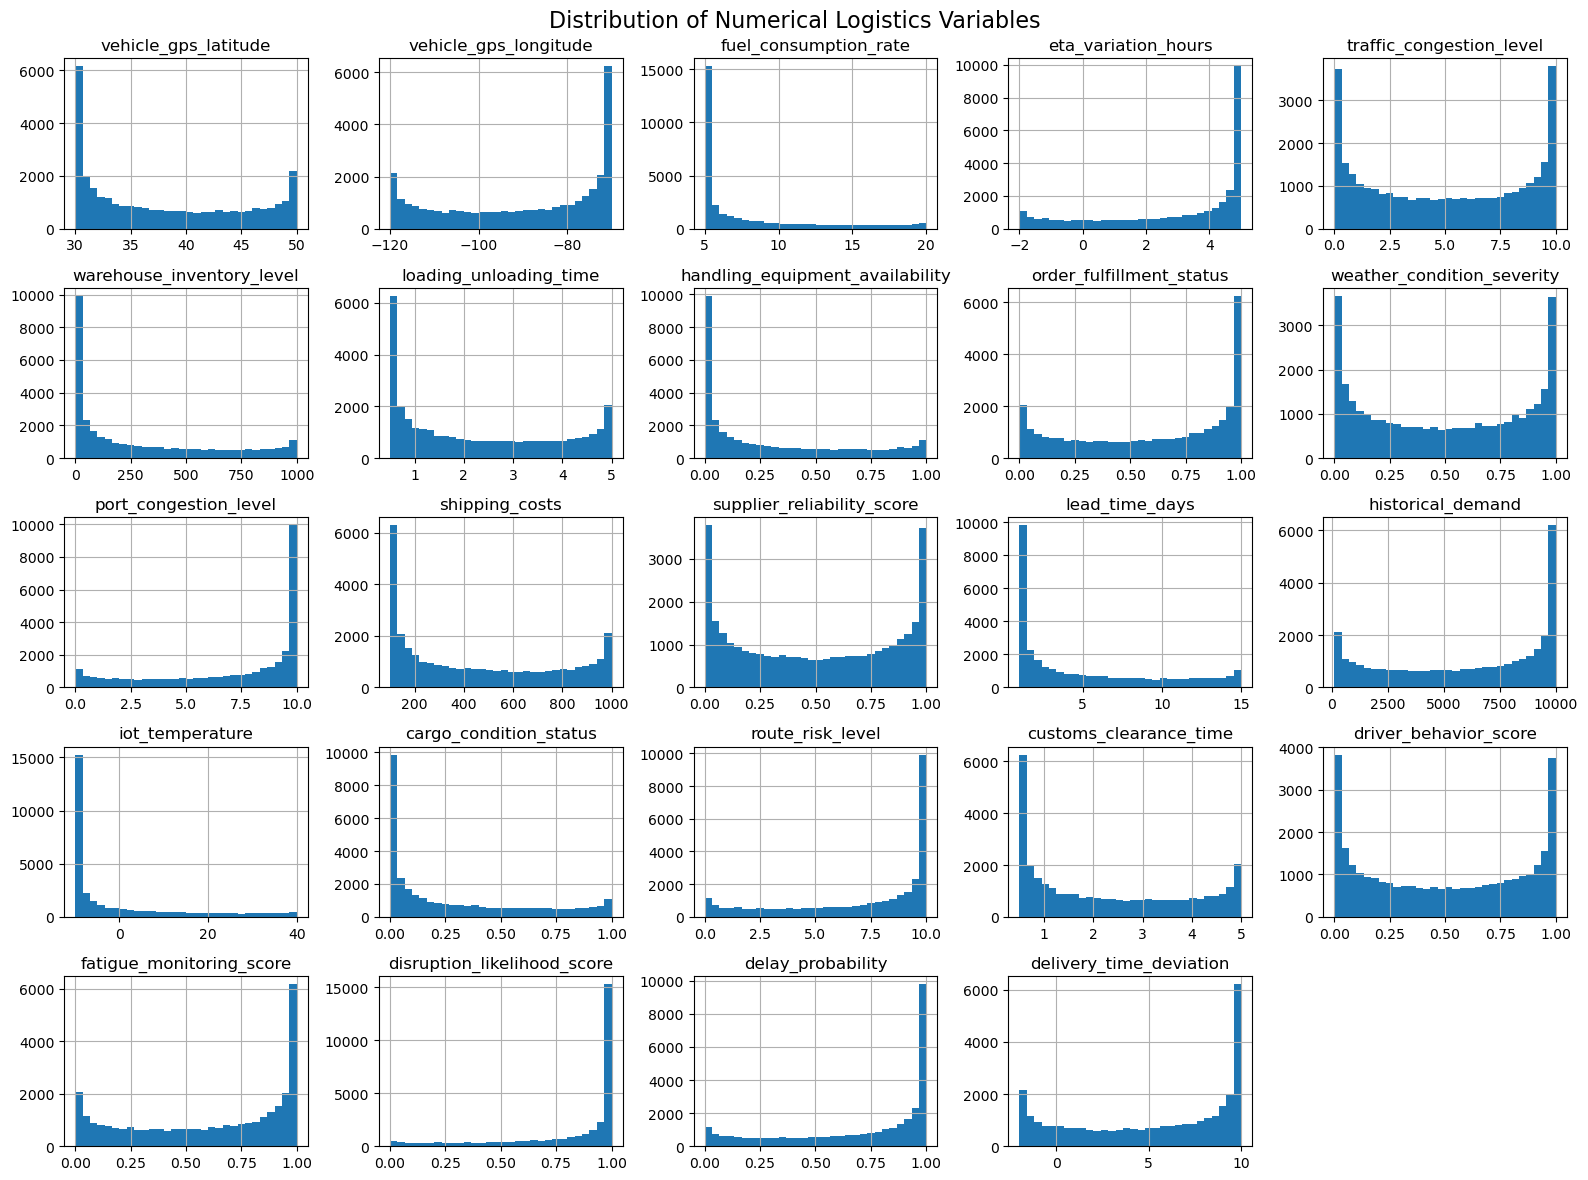

In [17]:
# Plot distributions of numerical variables

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Logistics Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [18]:
# Convert timestamp column to datetime format

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

print(df["timestamp"].dtype)

datetime64[ns]


In [19]:
# Check invalid/missing timestamps after conversion

invalid_timestamps = df["timestamp"].isnull().sum()

print("Invalid timestamps:", invalid_timestamps)

Invalid timestamps: 0


In [20]:
# Extract useful time-based features

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

df.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,year,month,day,hour,day_of_week
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.978599,0.506152,0.885291,Moderate Risk,9.110682,2021,1,1,0,4
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,0.918586,0.980784,0.544178,High Risk,8.175281,2021,1,1,1,4
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,0.394215,0.998633,0.803322,High Risk,1.283594,2021,1,1,2,4
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,0.905444,0.993320,0.025977,High Risk,9.304897,2021,1,1,3,4
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,0.258702,0.912433,0.991122,High Risk,7.752484,2021,1,1,4,4


In [21]:
# Display newly created time features

print(df[
    [
        "timestamp",
        "year",
        "month",
        "day",
        "hour",
        "day_of_week"
    ]
].head(10))

            timestamp  year  month  day  hour  day_of_week
0 2021-01-01 00:00:00  2021      1    1     0            4
1 2021-01-01 01:00:00  2021      1    1     1            4
2 2021-01-01 02:00:00  2021      1    1     2            4
3 2021-01-01 03:00:00  2021      1    1     3            4
4 2021-01-01 04:00:00  2021      1    1     4            4
5 2021-01-01 05:00:00  2021      1    1     5            4
6 2021-01-01 06:00:00  2021      1    1     6            4
7 2021-01-01 07:00:00  2021      1    1     7            4
8 2021-01-01 08:00:00  2021      1    1     8            4
9 2021-01-01 09:00:00  2021      1    1     9            4


## Step 4 — Data Cleaning

In [22]:
# Create a working copy for data cleaning

cleaned_df = df.copy()

print("Working copy created successfully.")
print("Shape:", cleaned_df.shape)

Working copy created successfully.
Shape: (32065, 31)


In [23]:
# Check missing values in the working dataset

missing_values = cleaned_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    print("Columns containing missing values:")
    print(missing_values)

No missing values found.


In [24]:
# Check duplicate records

duplicates = cleaned_df.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 0


In [25]:
# Remove duplicate records

before_duplicates = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

after_duplicates = len(cleaned_df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 32065
Rows after removing duplicates: 32065
Duplicates removed: 0


In [26]:
# Display current data types

cleaned_df.dtypes

timestamp                          datetime64[ns]
vehicle_gps_latitude                      float64
vehicle_gps_longitude                     float64
fuel_consumption_rate                     float64
eta_variation_hours                       float64
traffic_congestion_level                  float64
warehouse_inventory_level                 float64
loading_unloading_time                    float64
handling_equipment_availability           float64
order_fulfillment_status                  float64
weather_condition_severity                float64
port_congestion_level                     float64
shipping_costs                            float64
supplier_reliability_score                float64
lead_time_days                            float64
historical_demand                         float64
iot_temperature                           float64
cargo_condition_status                    float64
route_risk_level                          float64
customs_clearance_time                    float64


In [27]:
# Convert numerical columns to numeric data types

for col in numeric_columns:
    cleaned_df[col] = pd.to_numeric(
        cleaned_df[col],
        errors="coerce"
    )

print("Numerical data types validated.")

Numerical data types validated.


In [28]:
# Check whether datatype conversion created missing values

conversion_missing = cleaned_df.isnull().sum()

conversion_missing = conversion_missing[
    conversion_missing > 0
]

print("Missing values after type conversion:")

if len(conversion_missing) == 0:
    print("No missing values created.")
else:
    print(conversion_missing)

Missing values after type conversion:
No missing values created.


In [29]:
# Fill missing numerical values using the median

for col in numeric_columns:
    if cleaned_df[col].isnull().sum() > 0:
        cleaned_df[col] = cleaned_df[col].fillna(
            cleaned_df[col].median()
        )

In [30]:
# Fill missing categorical values using the mode

for col in categorical_columns:
    if cleaned_df[col].isnull().sum() > 0:
        mode_value = cleaned_df[col].mode()

        if len(mode_value) > 0:
            cleaned_df[col] = cleaned_df[col].fillna(
                mode_value.iloc[0]
            )

In [31]:
# Fill missing categorical values using the mode

for col in categorical_columns:
    if cleaned_df[col].isnull().sum() > 0:
        mode_value = cleaned_df[col].mode()

        if len(mode_value) > 0:
            cleaned_df[col] = cleaned_df[col].fillna(
                mode_value.iloc[0]
            )

In [32]:
# Check minimum values of numerical variables

minimum_values = cleaned_df[numeric_columns].min()

minimum_values

vehicle_gps_latitude               3.000000e+01
vehicle_gps_longitude             -1.200000e+02
fuel_consumption_rate              5.000000e+00
eta_variation_hours               -1.999993e+00
traffic_congestion_level           1.091633e-09
warehouse_inventory_level          1.322210e-12
loading_unloading_time             5.000000e-01
handling_equipment_availability    4.565769e-16
order_fulfillment_status           1.317764e-06
weather_condition_severity         4.536949e-09
port_congestion_level              1.778665e-06
shipping_costs                     1.000000e+02
supplier_reliability_score         6.904319e-10
lead_time_days                     1.000000e+00
historical_demand                  1.000030e+02
iot_temperature                   -1.000000e+01
cargo_condition_status             7.255415e-19
route_risk_level                   4.968185e-05
customs_clearance_time             5.000000e-01
driver_behavior_score              4.043927e-09
fatigue_monitoring_score           3.269

In [33]:
# Create outlier flags using the IQR method

outlier_flags = pd.DataFrame(index=cleaned_df.index)

for col in numeric_columns:
    
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_flags[col + "_outlier"] = (
        (cleaned_df[col] < lower_bound) |
        (cleaned_df[col] > upper_bound)
    )

outlier_flags.head()

,vehicle_gps_latitude_outlier,vehicle_gps_longitude_outlier,fuel_consumption_rate_outlier,eta_variation_hours_outlier,traffic_congestion_level_outlier,warehouse_inventory_level_outlier,loading_unloading_time_outlier,handling_equipment_availability_outlier,order_fulfillment_status_outlier,weather_condition_severity_outlier,...,historical_demand_outlier,iot_temperature_outlier,cargo_condition_status_outlier,route_risk_level_outlier,customs_clearance_time_outlier,driver_behavior_score_outlier,fatigue_monitoring_score_outlier,disruption_likelihood_score_outlier,delay_probability_outlier,delivery_time_deviation_outlier
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
# Final data-quality checks

print("FINAL DATA QUALITY CHECK")
print("=" * 40)

print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())
print("Timestamp datatype:", cleaned_df["timestamp"].dtype)

FINAL DATA QUALITY CHECK
Rows: 32065
Columns: 31
Missing values: 0
Duplicate rows: 0
Timestamp datatype: datetime64[ns]


## Step 5 — Normalization & Preprocessing

In [39]:
# Create a copy of the cleaned dataset

normalized_df = cleaned_df.copy()

print("Normalized dataset copy created.")
print("Shape:", normalized_df.shape)

Normalized dataset copy created.
Shape: (32065, 31)


In [41]:
# Apply Min-Max normalization to numerical columns

for col in numeric_columns:
    
    min_value = normalized_df[col].min()
    max_value = normalized_df[col].max()
    
    if max_value != min_value:
        normalized_df[col] = (
            normalized_df[col] - min_value
        ) / (max_value - min_value)
    else:
        normalized_df[col] = 0

print("Min-Max normalization completed.")

Min-Max normalization completed.


In [42]:
# Check minimum and maximum values after normalization

normalization_check = pd.DataFrame({
    "Column": numeric_columns,
    "Minimum": [
        normalized_df[col].min()
        for col in numeric_columns
    ],
    "Maximum": [
        normalized_df[col].max()
        for col in numeric_columns
    ]
})

normalization_check

,Column,Minimum,Maximum
0,vehicle_gps_latitude,0.0,1.0
1,vehicle_gps_longitude,0.0,1.0
2,fuel_consumption_rate,0.0,1.0
3,eta_variation_hours,0.0,1.0
4,traffic_congestion_level,0.0,1.0
5,warehouse_inventory_level,0.0,1.0
6,loading_unloading_time,0.0,1.0
7,handling_equipment_availability,0.0,1.0
8,order_fulfillment_status,0.0,1.0
9,weather_condition_severity,0.0,1.0


In [43]:
# Compare original and normalized statistics

comparison = pd.DataFrame({
    "Column": numeric_columns,
    "Original Mean": [
        cleaned_df[col].mean()
        for col in numeric_columns
    ],
    "Original Std": [
        cleaned_df[col].std()
        for col in numeric_columns
    ],
    "Normalized Mean": [
        normalized_df[col].mean()
        for col in numeric_columns
    ],
    "Normalized Std": [
        normalized_df[col].std()
        for col in numeric_columns
    ]
})

comparison

,Column,Original Mean,Original Std,Normalized Mean,Normalized Std
0,vehicle_gps_latitude,38.023589,6.917909,0.401179,0.345895
1,vehicle_gps_longitude,-90.116648,17.369244,0.597667,0.347385
2,fuel_consumption_rate,8.011735,4.264960,0.200784,0.284333
3,eta_variation_hours,2.893068,2.274044,0.699009,0.324864
4,traffic_congestion_level,4.991493,3.532048,0.499149,0.353205
5,warehouse_inventory_level,299.254732,323.443513,0.299255,0.323444
6,loading_unloading_time,2.291669,1.554202,0.398149,0.345378
7,handling_equipment_availability,0.302695,0.325915,0.302696,0.325915
8,order_fulfillment_status,0.600740,0.345672,0.600739,0.345673
9,weather_condition_severity,0.497608,0.353285,0.497608,0.353285


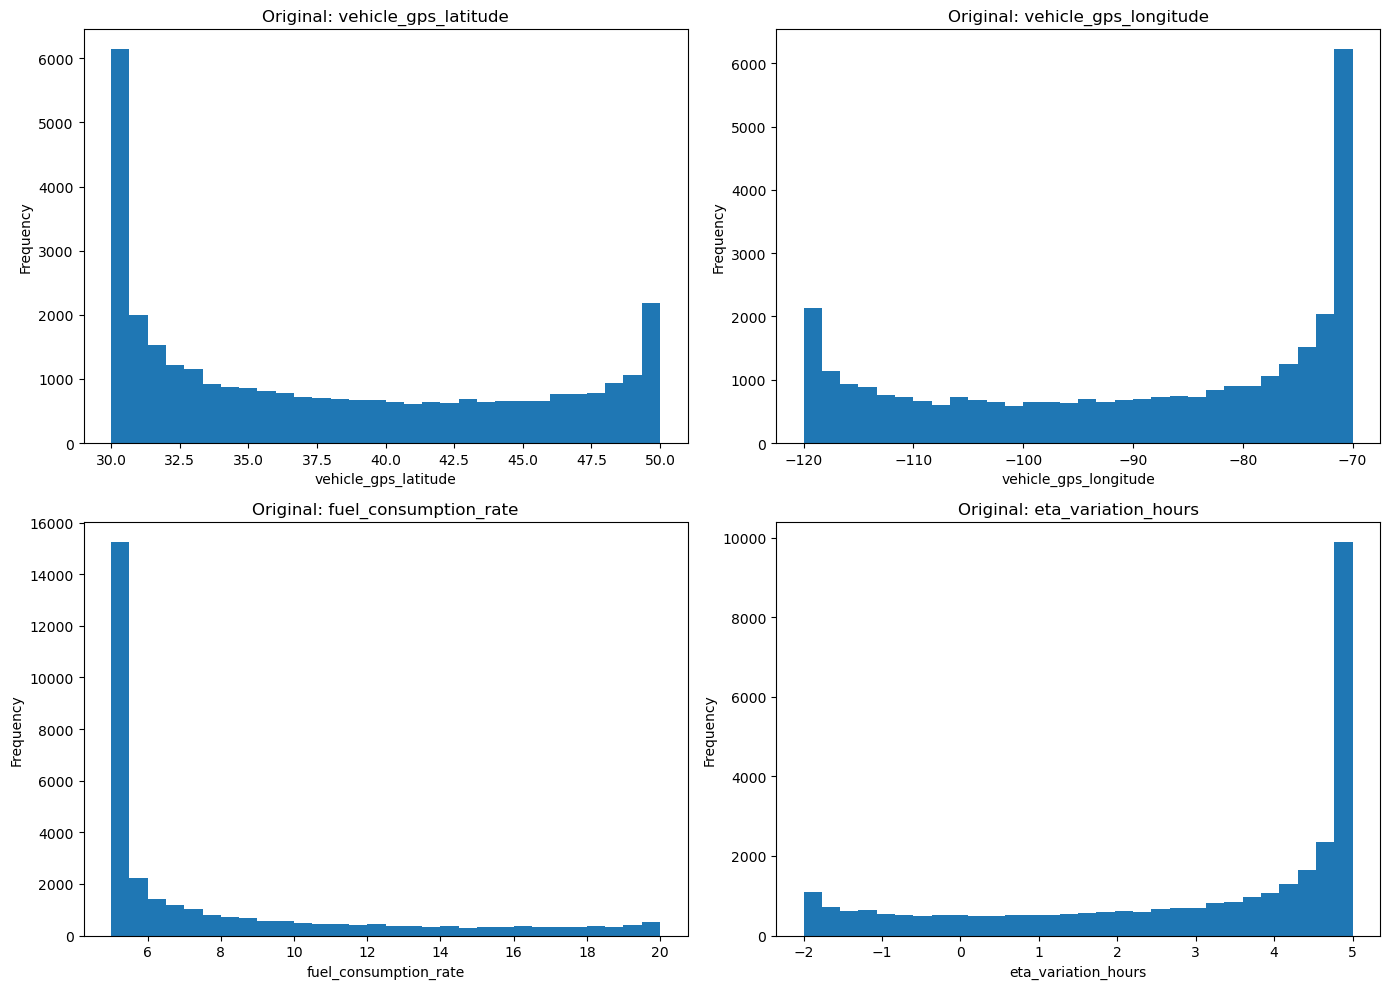

In [44]:
# Select a few numerical variables for visualization

selected_columns = numeric_columns[:4]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.flatten()

for i, col in enumerate(selected_columns):
    
    axes[i].hist(
        cleaned_df[col],
        bins=30
    )
    
    axes[i].set_title(
        f"Original: {col}"
    )
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

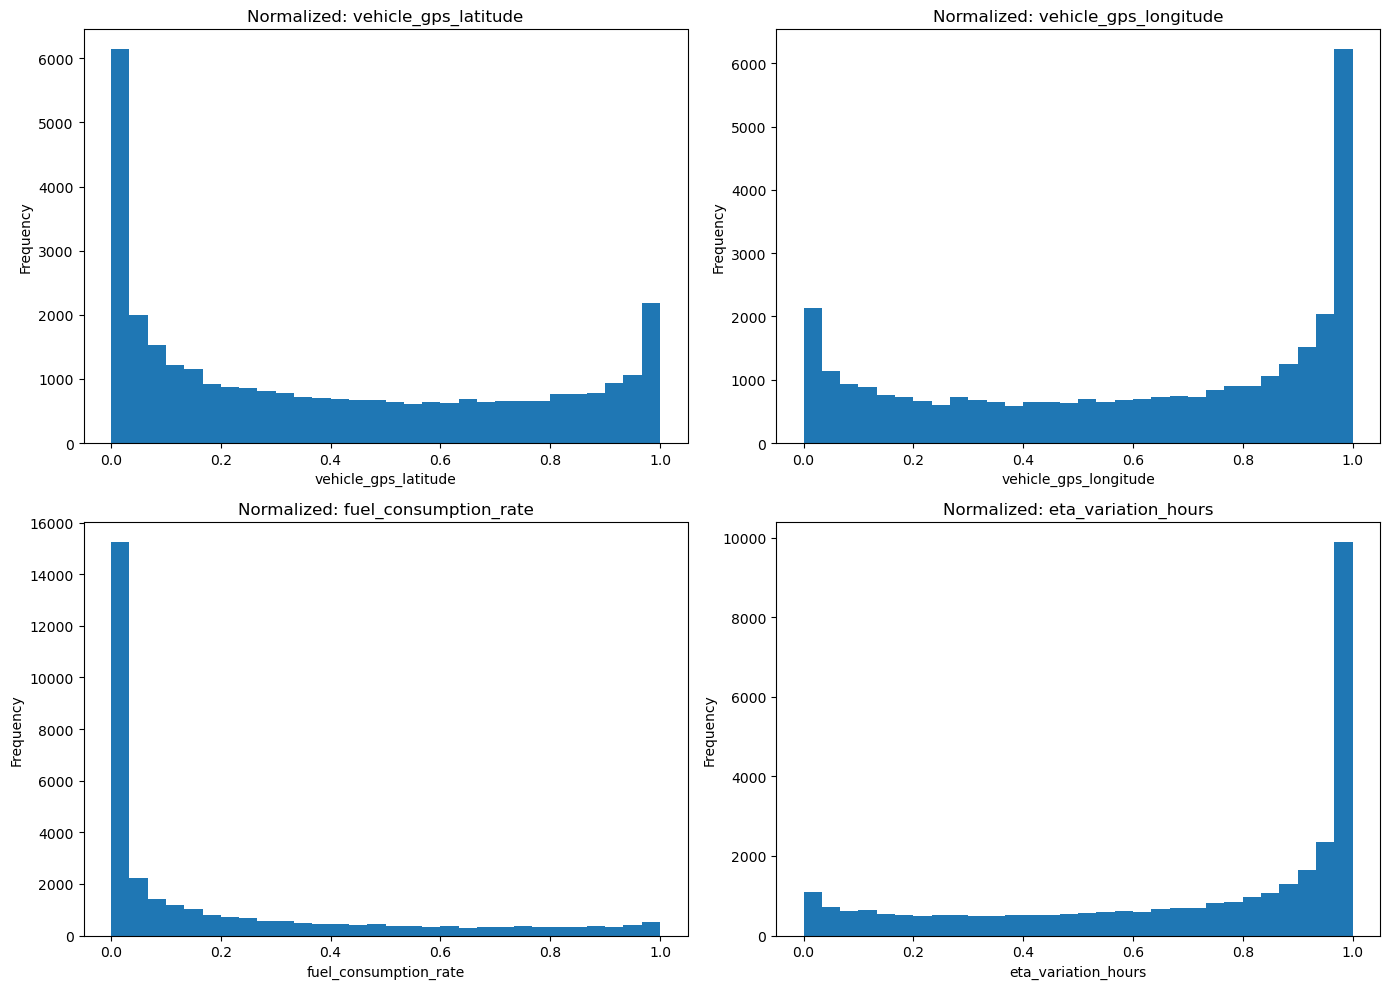

In [45]:
# Plot normalized distributions

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.flatten()

for i, col in enumerate(selected_columns):
    
    axes[i].hist(
        normalized_df[col],
        bins=30
    )
    
    axes[i].set_title(
        f"Normalized: {col}"
    )
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [46]:
# Calculate correlation matrix

correlation_matrix = cleaned_df[
    numeric_columns
].corr()

correlation_matrix

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
vehicle_gps_latitude,1.000000,0.006575,-0.002051,0.002856,-0.000294,0.002568,0.003429,-0.003693,0.005628,0.006376,...,0.004596,-0.001336,-0.002211,-0.012222,0.004441,-0.006078,-0.008915,-0.006788,-0.006185,0.000416
vehicle_gps_longitude,0.006575,1.000000,-0.002578,0.004960,-0.010364,-0.003587,-0.006421,-0.002189,0.001460,0.005315,...,-0.008845,0.007927,0.003344,0.003614,-0.003795,-0.006184,0.002398,0.000800,-0.005691,-0.001639
fuel_consumption_rate,-0.002051,-0.002578,1.000000,0.004064,0.005028,0.004062,0.004735,0.005117,-0.001407,-0.008411,...,-0.002226,0.007470,0.004966,0.009829,0.002723,-0.001414,-0.001881,0.002300,-0.013655,0.012495
eta_variation_hours,0.002856,0.004960,0.004064,1.000000,-0.004911,0.002014,-0.003600,-0.002190,-0.005203,0.006269,...,0.005310,-0.004108,0.001605,-0.005808,-0.003210,0.002218,0.006951,0.004189,-0.006897,-0.000746
traffic_congestion_level,-0.000294,-0.010364,0.005028,-0.004911,1.000000,0.009780,-0.014678,-0.001337,-0.001370,0.000698,...,0.001981,0.006053,-0.004870,0.006400,-0.003108,-0.000264,0.010069,0.000145,-0.003790,0.000510
warehouse_inventory_level,0.002568,-0.003587,0.004062,0.002014,0.009780,1.000000,0.000579,-0.005307,-0.005007,-0.011976,...,0.004388,0.004088,0.003896,0.004514,-0.005500,0.002880,-0.010713,-0.013536,0.004686,-0.007463
loading_unloading_time,0.003429,-0.006421,0.004735,-0.003600,-0.014678,0.000579,1.000000,0.007973,0.003916,0.003824,...,-0.006478,0.003213,-0.000013,-0.002197,0.007377,-0.001725,0.001803,0.002918,-0.000706,0.003375
handling_equipment_availability,-0.003693,-0.002189,0.005117,-0.002190,-0.001337,-0.005307,0.007973,1.000000,-0.004546,0.001767,...,-0.002886,-0.006315,-0.004692,-0.001362,-0.006250,0.005388,-0.007865,0.004005,0.002690,-0.004639
order_fulfillment_status,0.005628,0.001460,-0.001407,-0.005203,-0.001370,-0.005007,0.003916,-0.004546,1.000000,0.004263,...,0.003702,0.001685,0.007163,0.002856,-0.010632,0.001984,-0.000563,-0.008310,0.009730,0.003329
weather_condition_severity,0.006376,0.005315,-0.008411,0.006269,0.000698,-0.011976,0.003824,0.001767,0.004263,1.000000,...,-0.007898,0.003168,-0.001930,-0.006182,0.000040,-0.009517,0.002781,-0.000749,0.001503,-0.000541


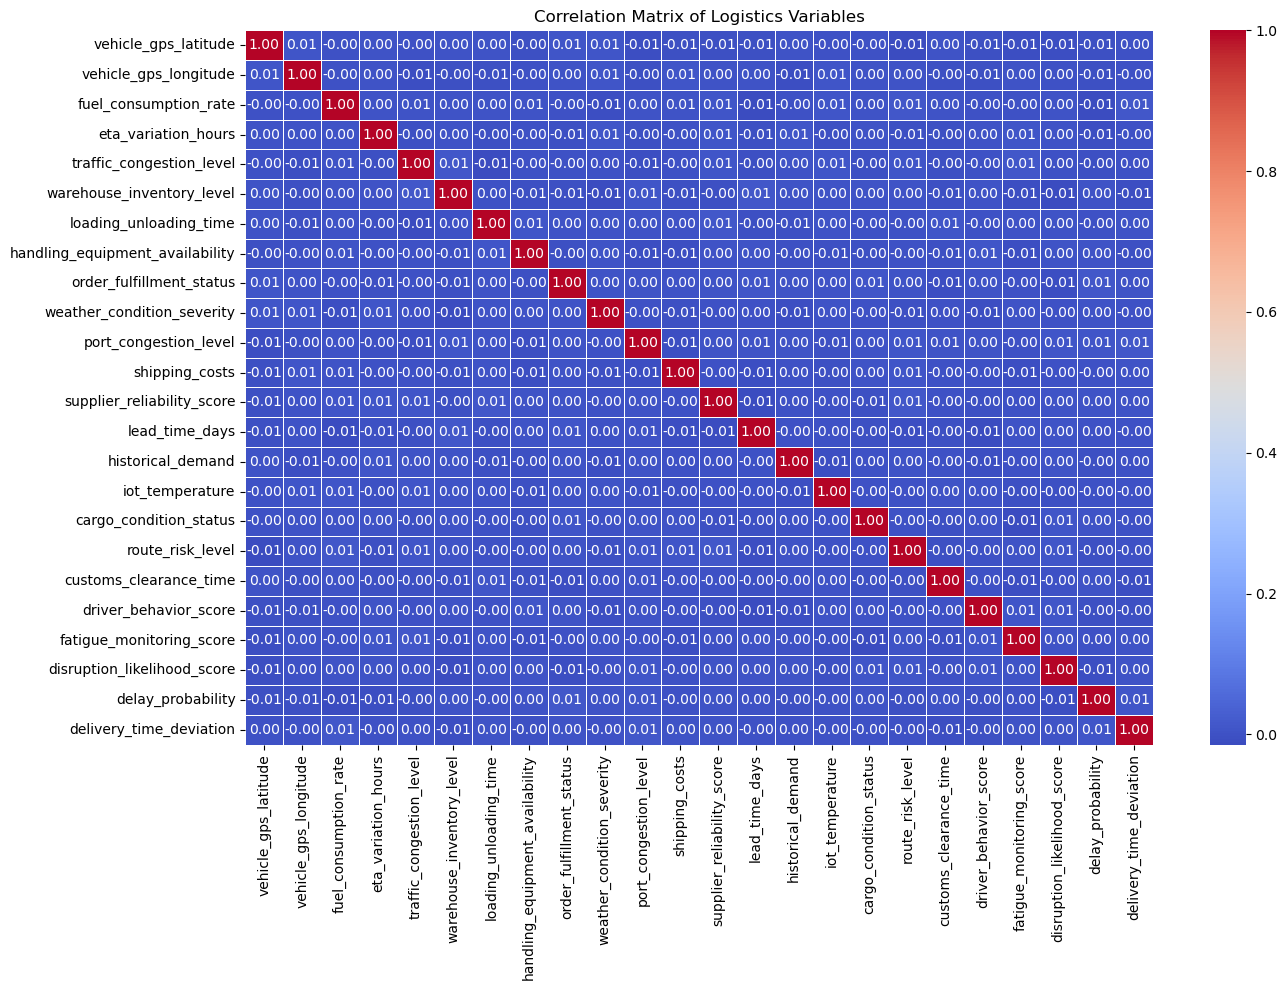

In [47]:
# Plot correlation heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Logistics Variables"
)

plt.tight_layout()
plt.show()

In [50]:
# Generate final preprocessing summary

summary = pd.DataFrame({
    "Metric": [
        "Original Rows",
        "Original Columns",
        "Final Rows",
        "Final Columns",
        "Missing Values",
        "Duplicate Rows",
        "Numerical Columns",
        "Categorical Columns"
    ],
    
    "Value": [
        df.shape[0],
        df.shape[1],
        cleaned_df.shape[0],
        cleaned_df.shape[1],
        cleaned_df.isnull().sum().sum(),
        cleaned_df.duplicated().sum(),
        len(numeric_columns),
        len(categorical_columns)
    ]
})

summary

,Metric,Value
0,Original Rows,32065
1,Original Columns,31
2,Final Rows,32065
3,Final Columns,31
4,Missing Values,0
5,Duplicate Rows,0
6,Numerical Columns,24
7,Categorical Columns,2


In [51]:
## Step 6 — Final Visualizations for the Report

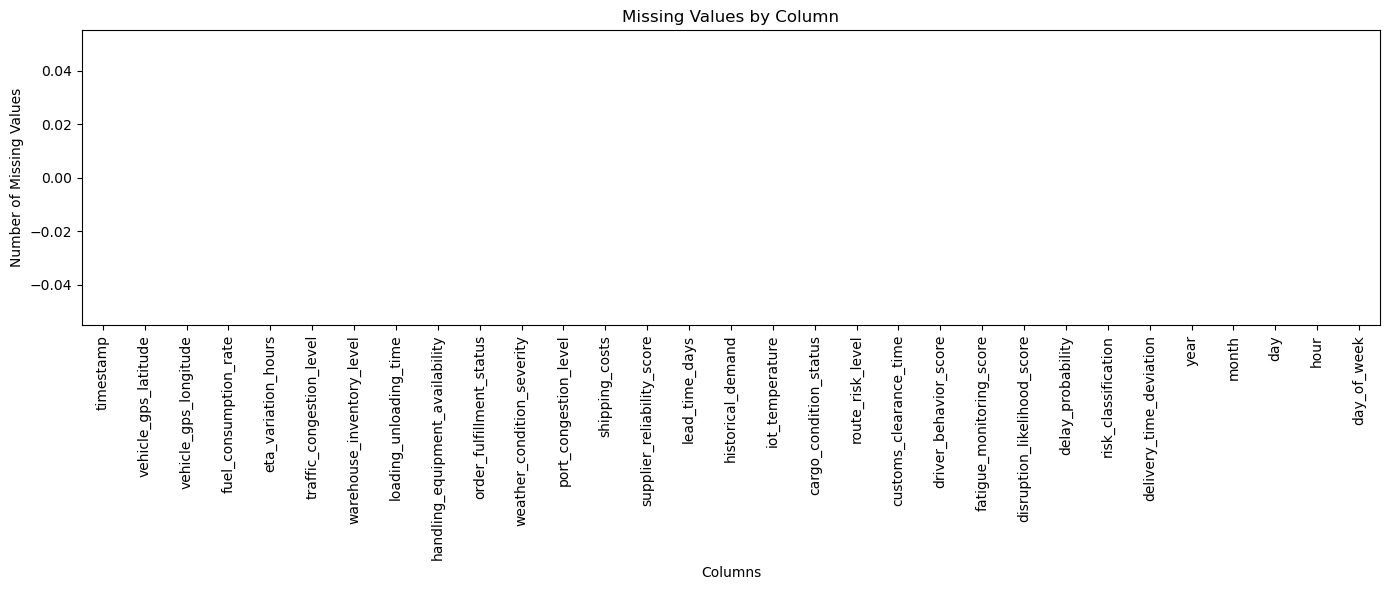

In [52]:
# Missing value analysis

missing_counts = cleaned_df.isnull().sum()

plt.figure(figsize=(14, 6))

missing_counts.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

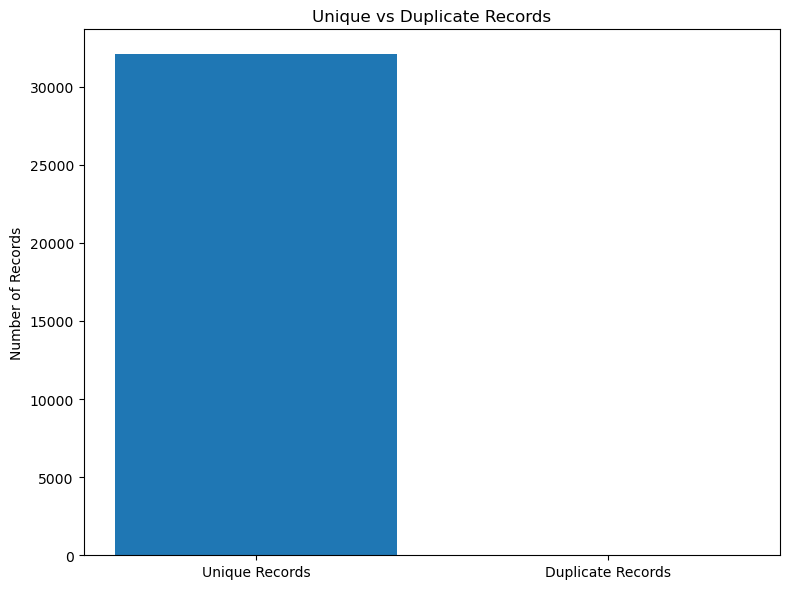

In [53]:
# Duplicate record analysis

duplicate_count = cleaned_df.duplicated().sum()
unique_count = len(cleaned_df) - duplicate_count

labels = ["Unique Records", "Duplicate Records"]
values = [unique_count, duplicate_count]

plt.figure(figsize=(8, 6))

plt.bar(labels, values)

plt.title("Unique vs Duplicate Records")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

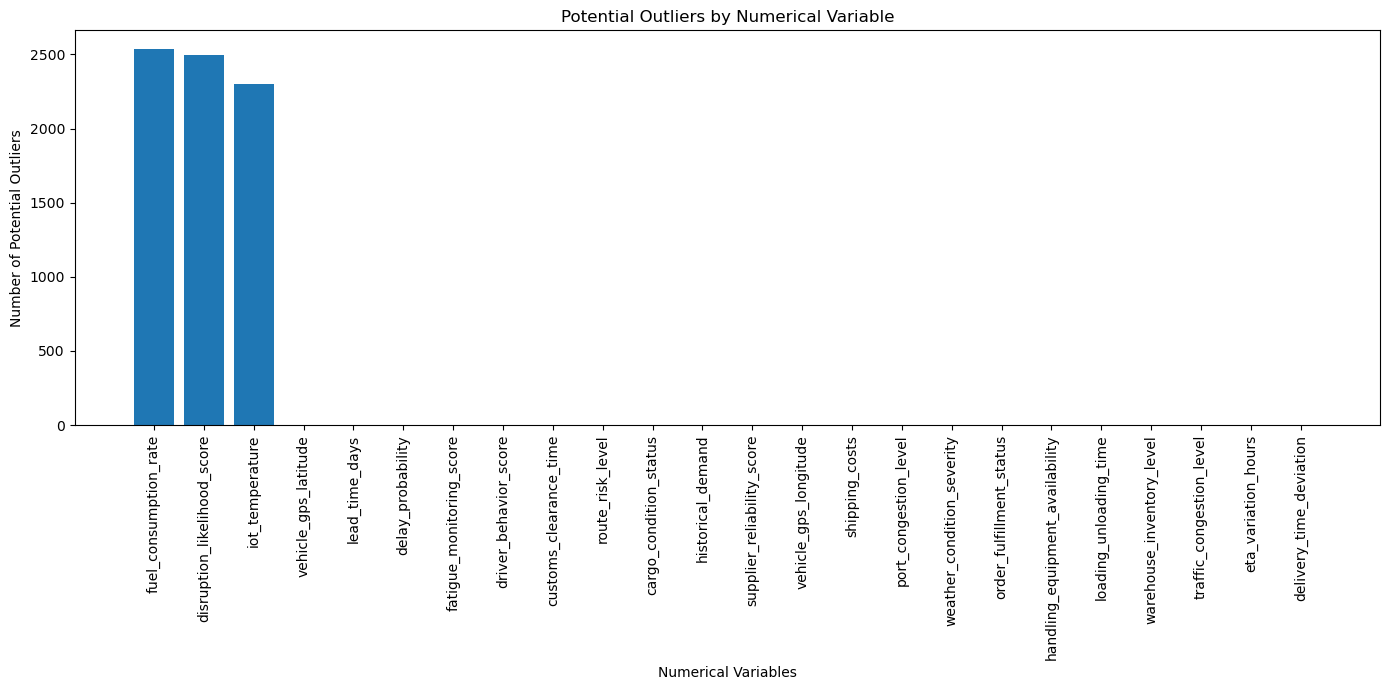

In [55]:
# Plot outlier counts

outlier_plot = outlier_summary.sort_values(
    by="Outlier Count",
    ascending=False
)

plt.figure(figsize=(14, 7))

plt.bar(
    outlier_plot["Column"],
    outlier_plot["Outlier Count"]
)

plt.title("Potential Outliers by Numerical Variable")
plt.xlabel("Numerical Variables")
plt.ylabel("Number of Potential Outliers")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

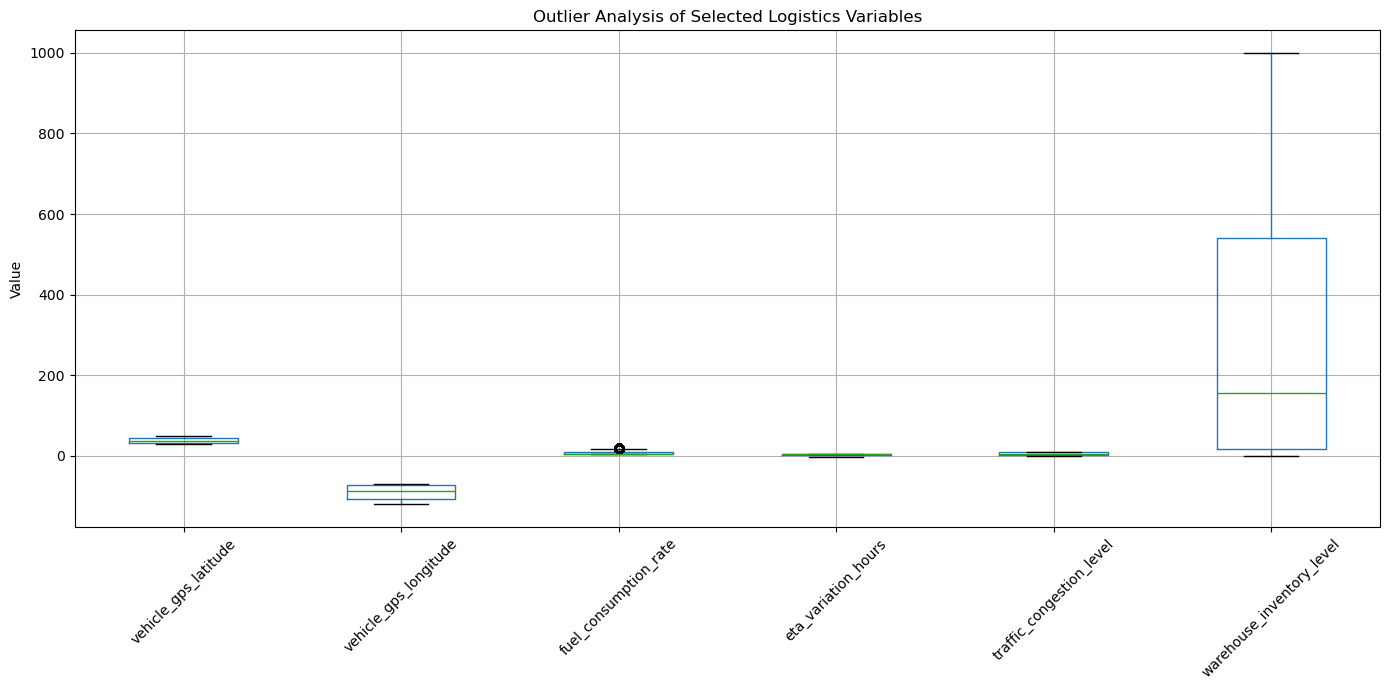

In [56]:
# Select variables for detailed outlier visualization

selected_outlier_columns = numeric_columns[:6]

plt.figure(figsize=(14, 7))

cleaned_df[selected_outlier_columns].boxplot()

plt.title("Outlier Analysis of Selected Logistics Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

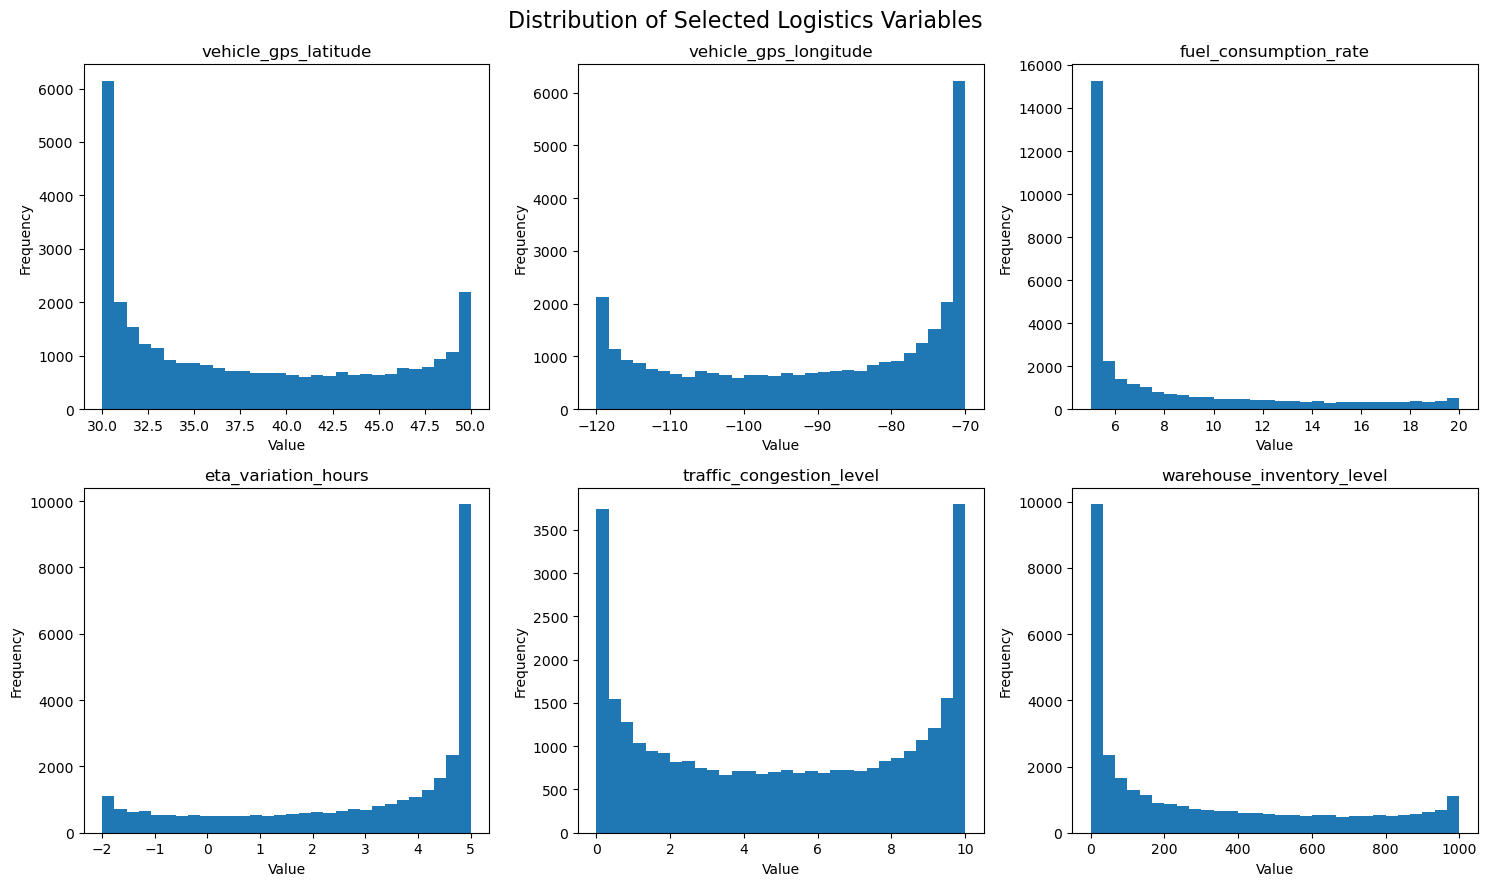

In [57]:
# Distribution analysis of selected logistics variables

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, col in enumerate(selected_outlier_columns):
    
    axes[i].hist(
        cleaned_df[col],
        bins=30
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Selected Logistics Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

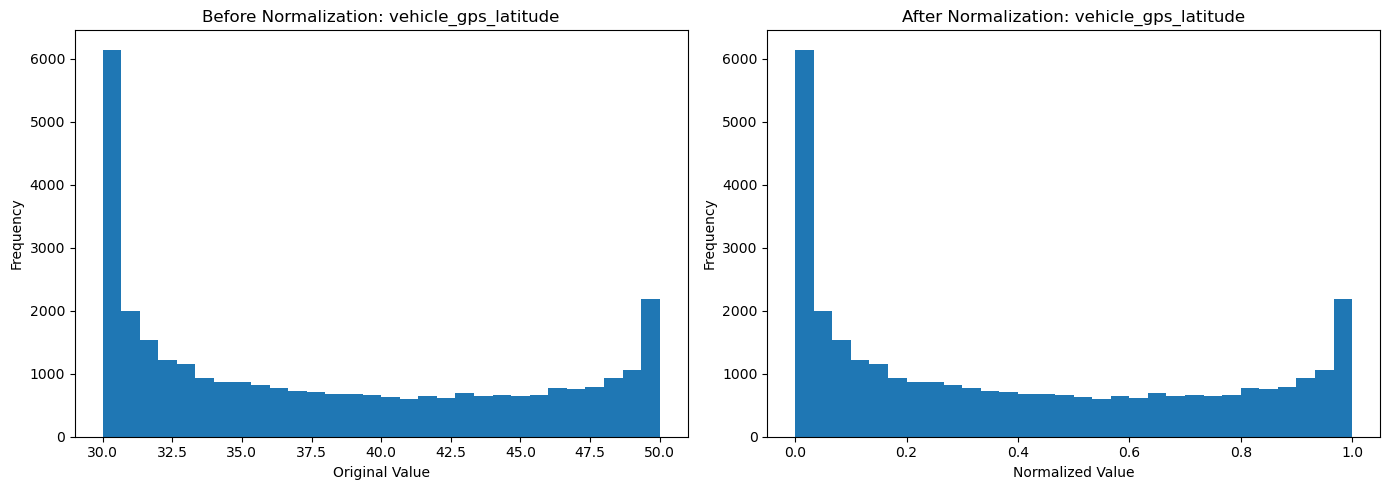

In [58]:
# Compare original and normalized data

comparison_column = numeric_columns[0]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Original
axes[0].hist(
    cleaned_df[comparison_column],
    bins=30
)

axes[0].set_title(
    f"Before Normalization: {comparison_column}"
)

axes[0].set_xlabel("Original Value")
axes[0].set_ylabel("Frequency")

# Normalized
axes[1].hist(
    normalized_df[comparison_column],
    bins=30
)

axes[1].set_title(
    f"After Normalization: {comparison_column}"
)

axes[1].set_xlabel("Normalized Value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

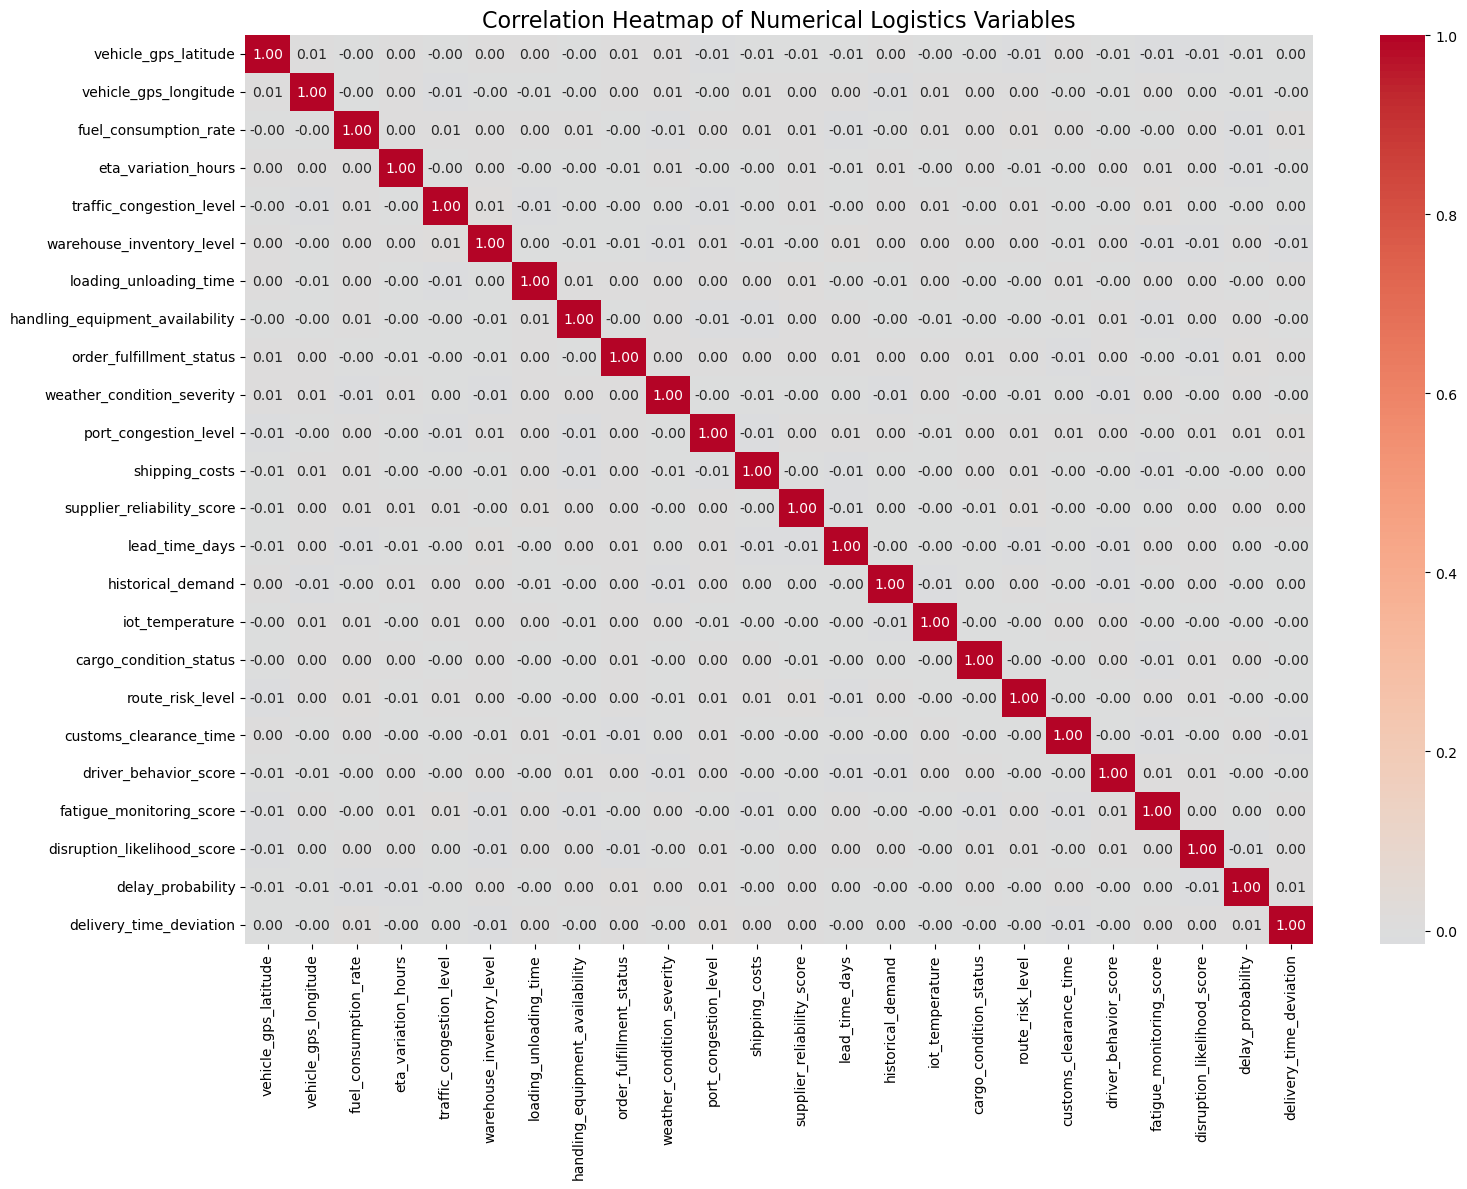

In [59]:
# Final correlation heatmap

plt.figure(figsize=(16, 12))

sns.heatmap(
    cleaned_df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap of Numerical Logistics Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [60]:
# Final verification

print("FINAL DATASET VERIFICATION")
print("=" * 45)

print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

print("\nData types:")
print(cleaned_df.dtypes)

FINAL DATASET VERIFICATION
Rows: 32065
Columns: 31
Missing values: 0
Duplicate rows: 0

Data types:
timestamp                          datetime64[ns]
vehicle_gps_latitude                      float64
vehicle_gps_longitude                     float64
fuel_consumption_rate                     float64
eta_variation_hours                       float64
traffic_congestion_level                  float64
warehouse_inventory_level                 float64
loading_unloading_time                    float64
handling_equipment_availability           float64
order_fulfillment_status                  float64
weather_condition_severity                float64
port_congestion_level                     float64
shipping_costs                            float64
supplier_reliability_score                float64
lead_time_days                            float64
historical_demand                         float64
iot_temperature                           float64
cargo_condition_status                    float64
